# Random Forest

   Carbonization Temp (C)  Id/Ig  Interlayer Spacing (Å)  \
0                     900  3.420                    3.85   
1                    1100  3.000                    3.83   
2                    1100  3.250                    3.99   
3                    1300  1.813                    3.81   
4                    1300  1.533                    3.83   

   Specific surface Area (m2/g)  ICE (%)  Reversible Capacity (mAh/g)  
0                        279.50    80.10                        217.8  
1                          9.20    88.90                        299.4  
2                         57.40    80.60                        272.0  
3                         51.25    56.14                        236.1  
4                         99.94    52.50                        220.0  


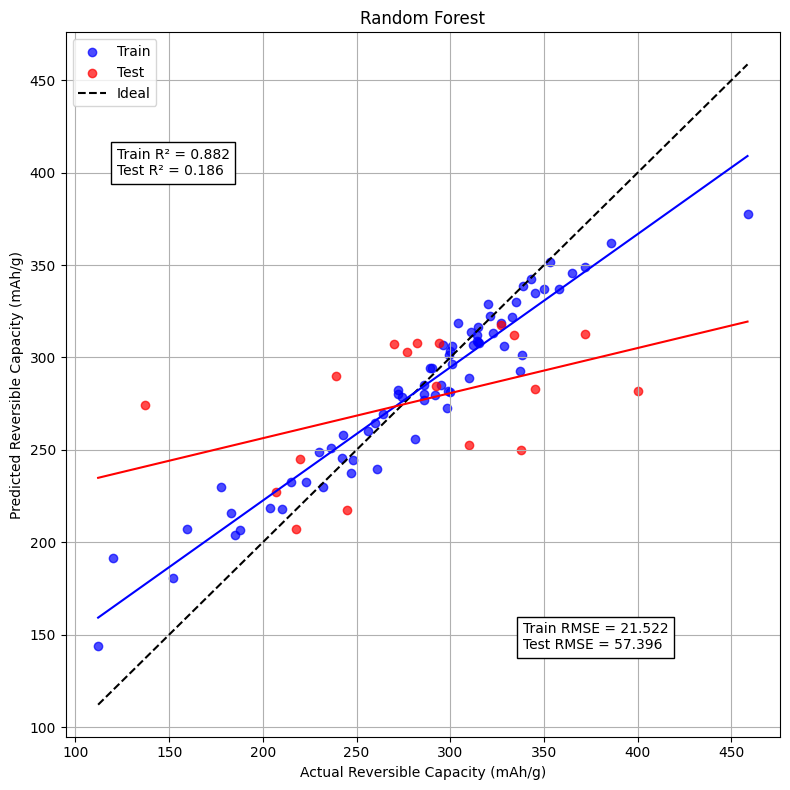

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Load your Excel file
# Replace 'data.xlsx' with your actual file name
df = pd.read_excel('Battery.xlsx')

# Preview data
print(df.head())

df.columns = df.columns.str.strip()

# Features (inputs) and target (output)
X = df[['Carbonization Temp (C)', 'Id/Ig', 'Interlayer Spacing (Å)', 'Specific surface Area (m2/g)']]
y = df['Reversible Capacity (mAh/g)']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)


# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


# ---- Predict for new input ----
# Example: Power=60, Speed=18, DPI=400, Defocus=0.1
#new_data = pd.DataFrame([[60, 18, 400, 0.1]],columns=['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)'])

#prediction = model.predict(new_data)
#print("Predicted Sheet Resistance:", prediction[0])



# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Reversible Capacity (mAh/g)")
plt.ylabel("Predicted Reversible Capacity (mAh/g)")
plt.title("Random Forest")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Support Vector Regression (SVR)

   Carbonization Temp (C)  Id/Ig  Interlayer Spacing (Å)  \
0                     900  3.420                    3.85   
1                    1100  3.000                    3.83   
2                    1100  3.250                    3.99   
3                    1300  1.813                    3.81   
4                    1300  1.533                    3.83   

   Specific surface Area (m2/g)  ICE (%)  Reversible Capacity (mAh/g)  
0                        279.50    80.10                        217.8  
1                          9.20    88.90                        299.4  
2                         57.40    80.60                        272.0  
3                         51.25    56.14                        236.1  
4                         99.94    52.50                        220.0  


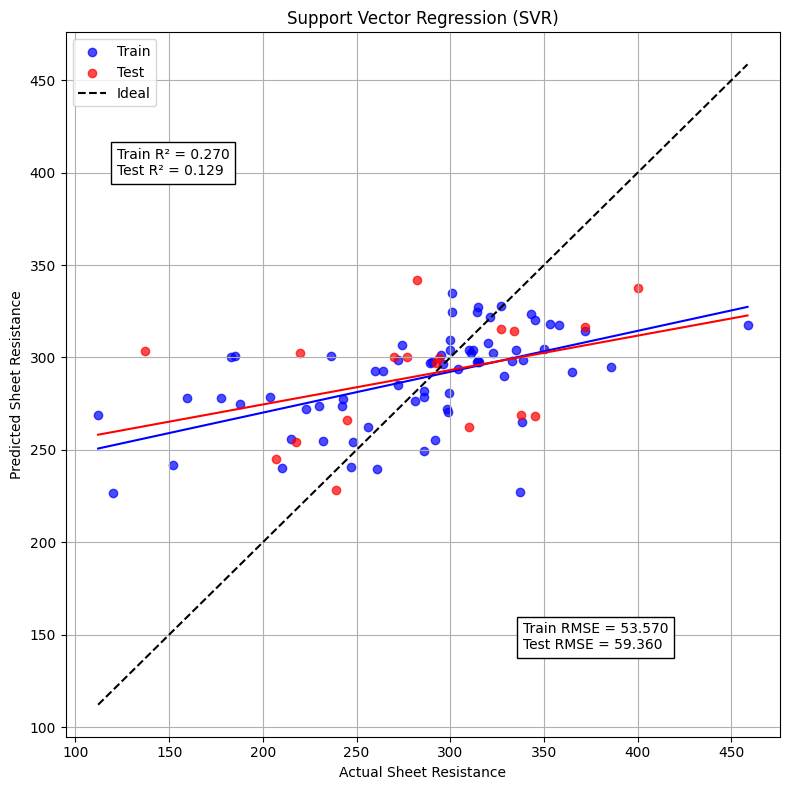

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load your Excel file
# Replace 'data.xlsx' with your actual file name
df = pd.read_excel('Battery.xlsx')

# Preview data
print(df.head())

df.columns = df.columns.str.strip()

# Features (inputs) and target (output)
X = df[['Carbonization Temp (C)', 'Id/Ig', 'Interlayer Spacing (Å)', 'Specific surface Area (m2/g)']]
y = df['Reversible Capacity (mAh/g)']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# SCALE X and Y PROPERLY
# -------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# -------------------------
# BETTER SVR SETTINGS
# -------------------------
model = SVR(
    kernel='rbf',
    C=10,          # MUCH smaller
    gamma=0.01,   # smoother function
    epsilon=0.1   # more tolerance (prevents overfitting)
)

model.fit(X_train_s, y_train_s)

# Predictions
y_train_pred_s = model.predict(X_train_s)
y_test_pred_s = model.predict(X_test_s)

# Inverse transform
y_train_pred = y_scaler.inverse_transform(y_train_pred_s.reshape(-1,1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_s.reshape(-1,1)).ravel()

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Support Vector Regression (SVR)")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Decision Tree (DT)

   Carbonization Temp (C)  Id/Ig  Interlayer Spacing (Å)  \
0                     900  3.420                    3.85   
1                    1100  3.000                    3.83   
2                    1100  3.250                    3.99   
3                    1300  1.813                    3.81   
4                    1300  1.533                    3.83   

   Specific surface Area (m2/g)  ICE (%)  Reversible Capacity (mAh/g)  
0                        279.50    80.10                        217.8  
1                          9.20    88.90                        299.4  
2                         57.40    80.60                        272.0  
3                         51.25    56.14                        236.1  
4                         99.94    52.50                        220.0  


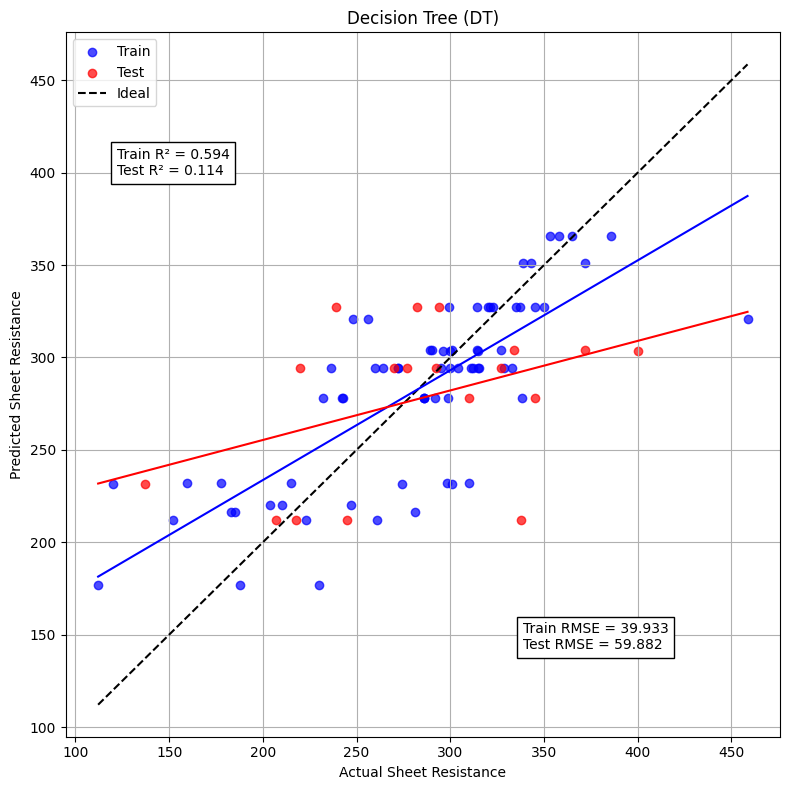

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
# Load your Excel file
# Replace 'data.xlsx' with your actual file name
df = pd.read_excel('Battery.xlsx')

# Preview data
print(df.head())

df.columns = df.columns.str.strip()

# Features (inputs) and target (output)
X = df[['Carbonization Temp (C)', 'Id/Ig', 'Interlayer Spacing (Å)', 'Specific surface Area (m2/g)']]
y = df['Reversible Capacity (mAh/g)']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Model (controlled depth to avoid overfitting)
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,
    min_samples_leaf=3
)

model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -----------------------
# METRICS

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Decision Tree (DT)")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# K-Nearest Neighbors (KNN) 

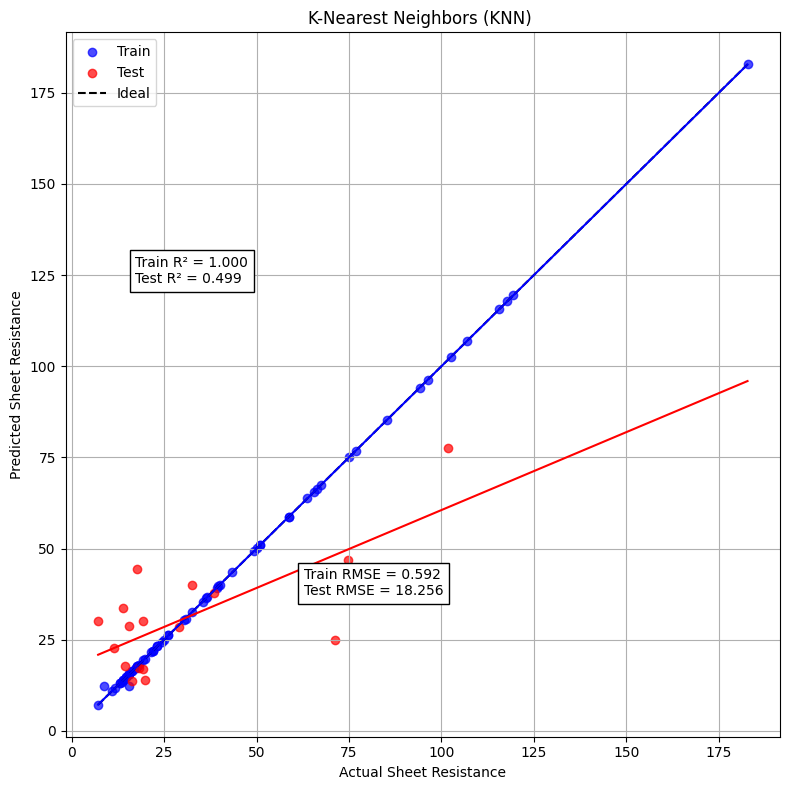

In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# SCALING (VERY IMPORTANT)
# -----------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------
# KNN MODEL
# -----------------------
model = KNeighborsRegressor(
    n_neighbors=4,   # you can tune this
    weights='distance'  # better than uniform for regression
)

model.fit(X_train_s, y_train)

# Predictions
y_train_pred = model.predict(X_train_s)
y_test_pred = model.predict(X_test_s)

# -----------------------
# METRICS

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("K-Nearest Neighbors (KNN) ")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Neural Network

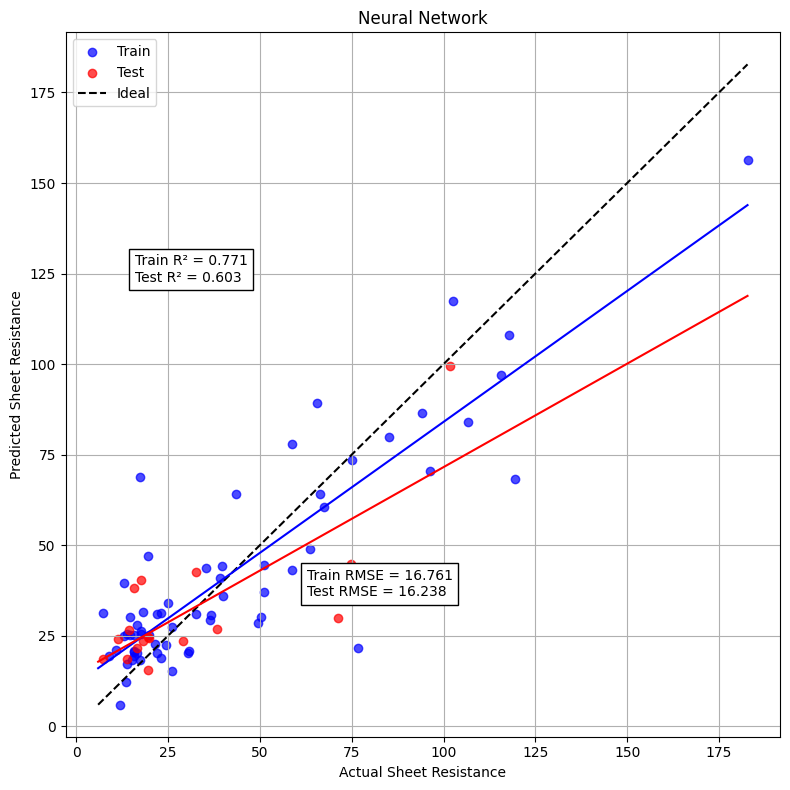

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler_X", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        alpha=0.01,              # stronger regularization
        learning_rate_init=0.0005,
        max_iter=5000,
        early_stopping=True,     # prevents overfitting
        n_iter_no_change=50,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Neural Network")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Gaussian Process Regression (GPR)

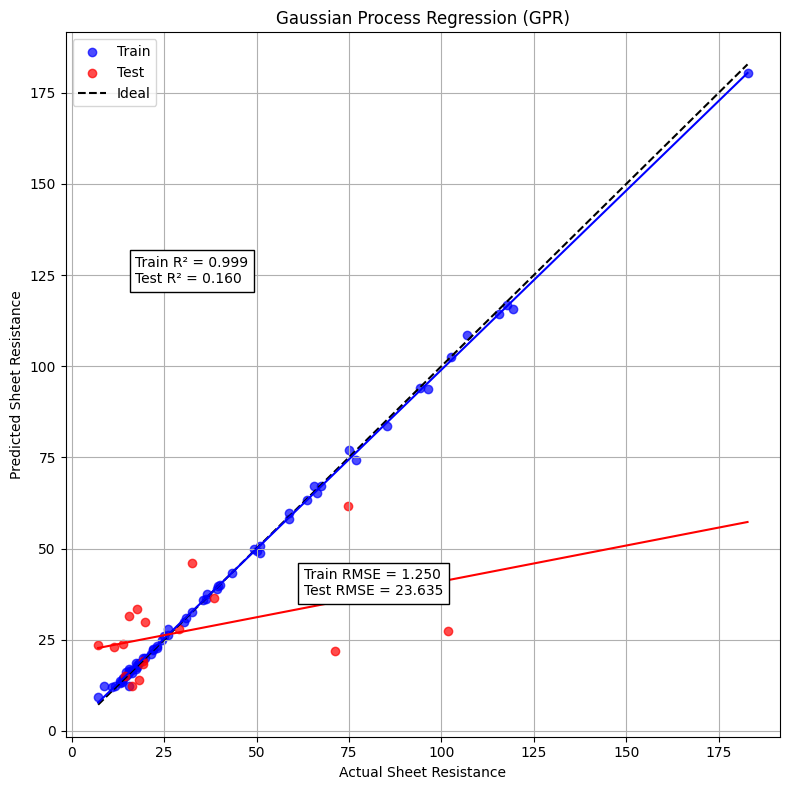

In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------
# LOAD DATA
# -----------------------
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# -----------------------
# SPLIT
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# SCALING (IMPORTANT)
# -----------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------
# GPR MODEL (RBF + noise kernel)
# -----------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel()

model = GaussianProcessRegressor(
    kernel=kernel,
    random_state=42,
    normalize_y=True
)

# Train
model.fit(X_train_s, y_train)

# -----------------------
# PREDICTIONS
# -----------------------
y_train_pred, y_train_std = model.predict(X_train_s, return_std=True)
y_test_pred, y_test_std = model.predict(X_test_s, return_std=True)

# -----------------------
# METRICS
# -----------------------
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Gaussian Process Regression (GPR)")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# XGBoost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load your Excel file
# Replace 'data.xlsx' with your actual file name
df = pd.read_excel('Battery.xlsx')

# Preview data
print(df.head())

df.columns = df.columns.str.strip()

# Features (inputs) and target (output)
X = df[['Carbonization Temp (C)', 'Id/Ig', 'Interlayer Spacing (Å)', 'Specific surface Area (m2/g)']]
y = df['Reversible Capacity (mAh/g)']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# XGBoost model
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("XGBoost")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

   Carbonization Temp (C)  Id/Ig  Interlayer Spacing (Å)  \
0                     900  3.420                    3.85   
1                    1100  3.000                    3.83   
2                    1100  3.250                    3.99   
3                    1300  1.813                    3.81   
4                    1300  1.533                    3.83   

   Specific surface Area (m2/g)  ICE (%)  Reversible Capacity (mAh/g)  
0                        279.50    80.10                        217.8  
1                          9.20    88.90                        299.4  
2                         57.40    80.60                        272.0  
3                         51.25    56.14                        236.1  
4                         99.94    52.50                        220.0  
